In [1]:
!nvidia-smi

Thu Jun 11 03:40:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.0 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip "/content/drive/MyDrive/RoadDamageDetection.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/RoadDamageDetection/labels/train/India_004338.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004339.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004341.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004342.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004343.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004344.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004345.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004346.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004348.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004349.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004352.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_004354.txt  
  inflating: /content/RoadDamageDetection/labels/train/India_

In [5]:
!ls /content/RoadDamageDetection

check_classes.py	data.yaml  labels	     train.py
convert_xml_to_yolo.py	images	   split_dataset.py  yolov8n.pt


In [8]:
with open("/content/RoadDamageDetection/data.yaml", "w") as f:
    f.write("""
path: /content/RoadDamageDetection

train: images/train
val: images/val

nc: 8

names:
  0: D00
  1: D01
  2: D10
  3: D11
  4: D20
  5: D40
  6: D43
  7: D44
""")

In [9]:
!ls /content/RoadDamageDetection

check_classes.py	data.yaml  labels	     train.py
convert_xml_to_yolo.py	images	   split_dataset.py  yolov8n.pt


In [10]:
!ls /content/RoadDamageDetection/images

train  val


In [11]:
!ls /content/RoadDamageDetection/labels

backup_labels  train  val


In [12]:
import os

print("Train Images:",
      len(os.listdir("/content/RoadDamageDetection/images/train")))

print("Val Images:",
      len(os.listdir("/content/RoadDamageDetection/images/val")))

print("Train Labels:",
      len(os.listdir("/content/RoadDamageDetection/labels/train")))

print("Val Labels:",
      len(os.listdir("/content/RoadDamageDetection/labels/val")))

Train Images: 6164
Val Images: 1542
Train Labels: 6164
Val Labels: 1542


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/RoadDamageDetection/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RoadDamageDetection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b7caceffaa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [14]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

In [17]:
results = model.predict(
    source="RoadDamageDetection/images/train/India_000011.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/RoadDamageDetection/images/train/India_000011.jpg: 640x640 1 D00, 8.6ms
Speed: 3.3ms preprocess, 8.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


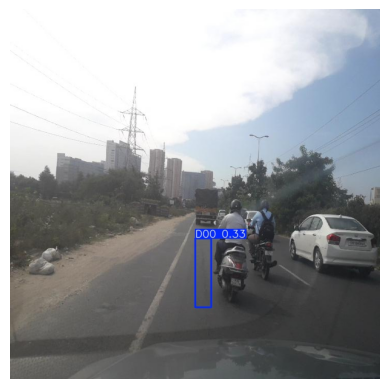

In [19]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("/content/runs/detect/predict/India_000011.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
from google.colab import files

files.download(
    "/content/runs/detect/train-2/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

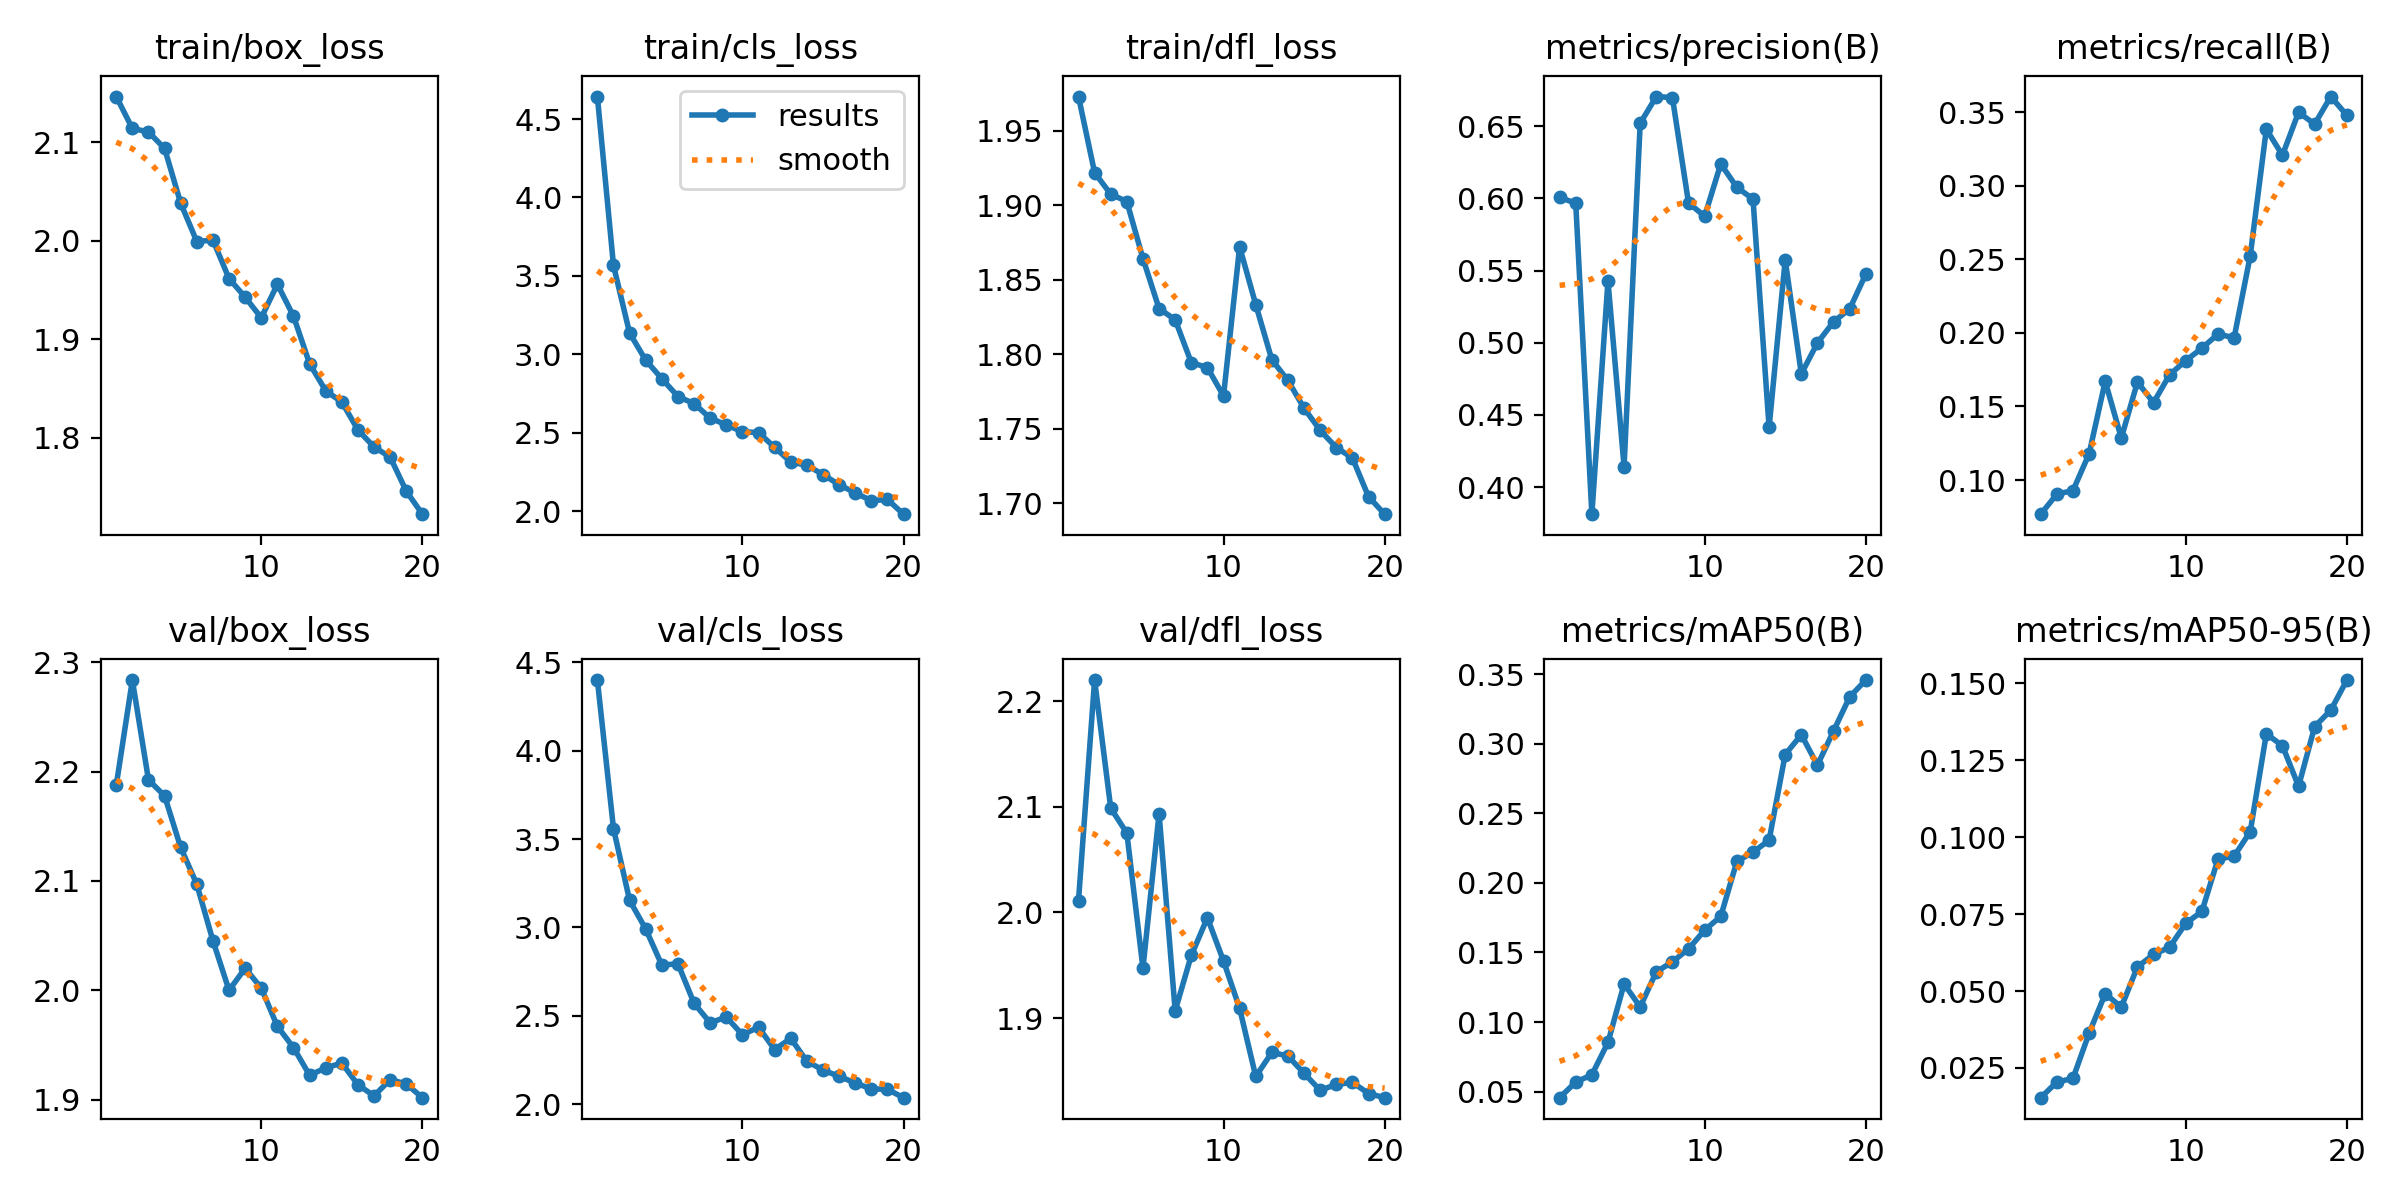

In [21]:
from IPython.display import Image

Image("/content/runs/detect/train-2/results.png")

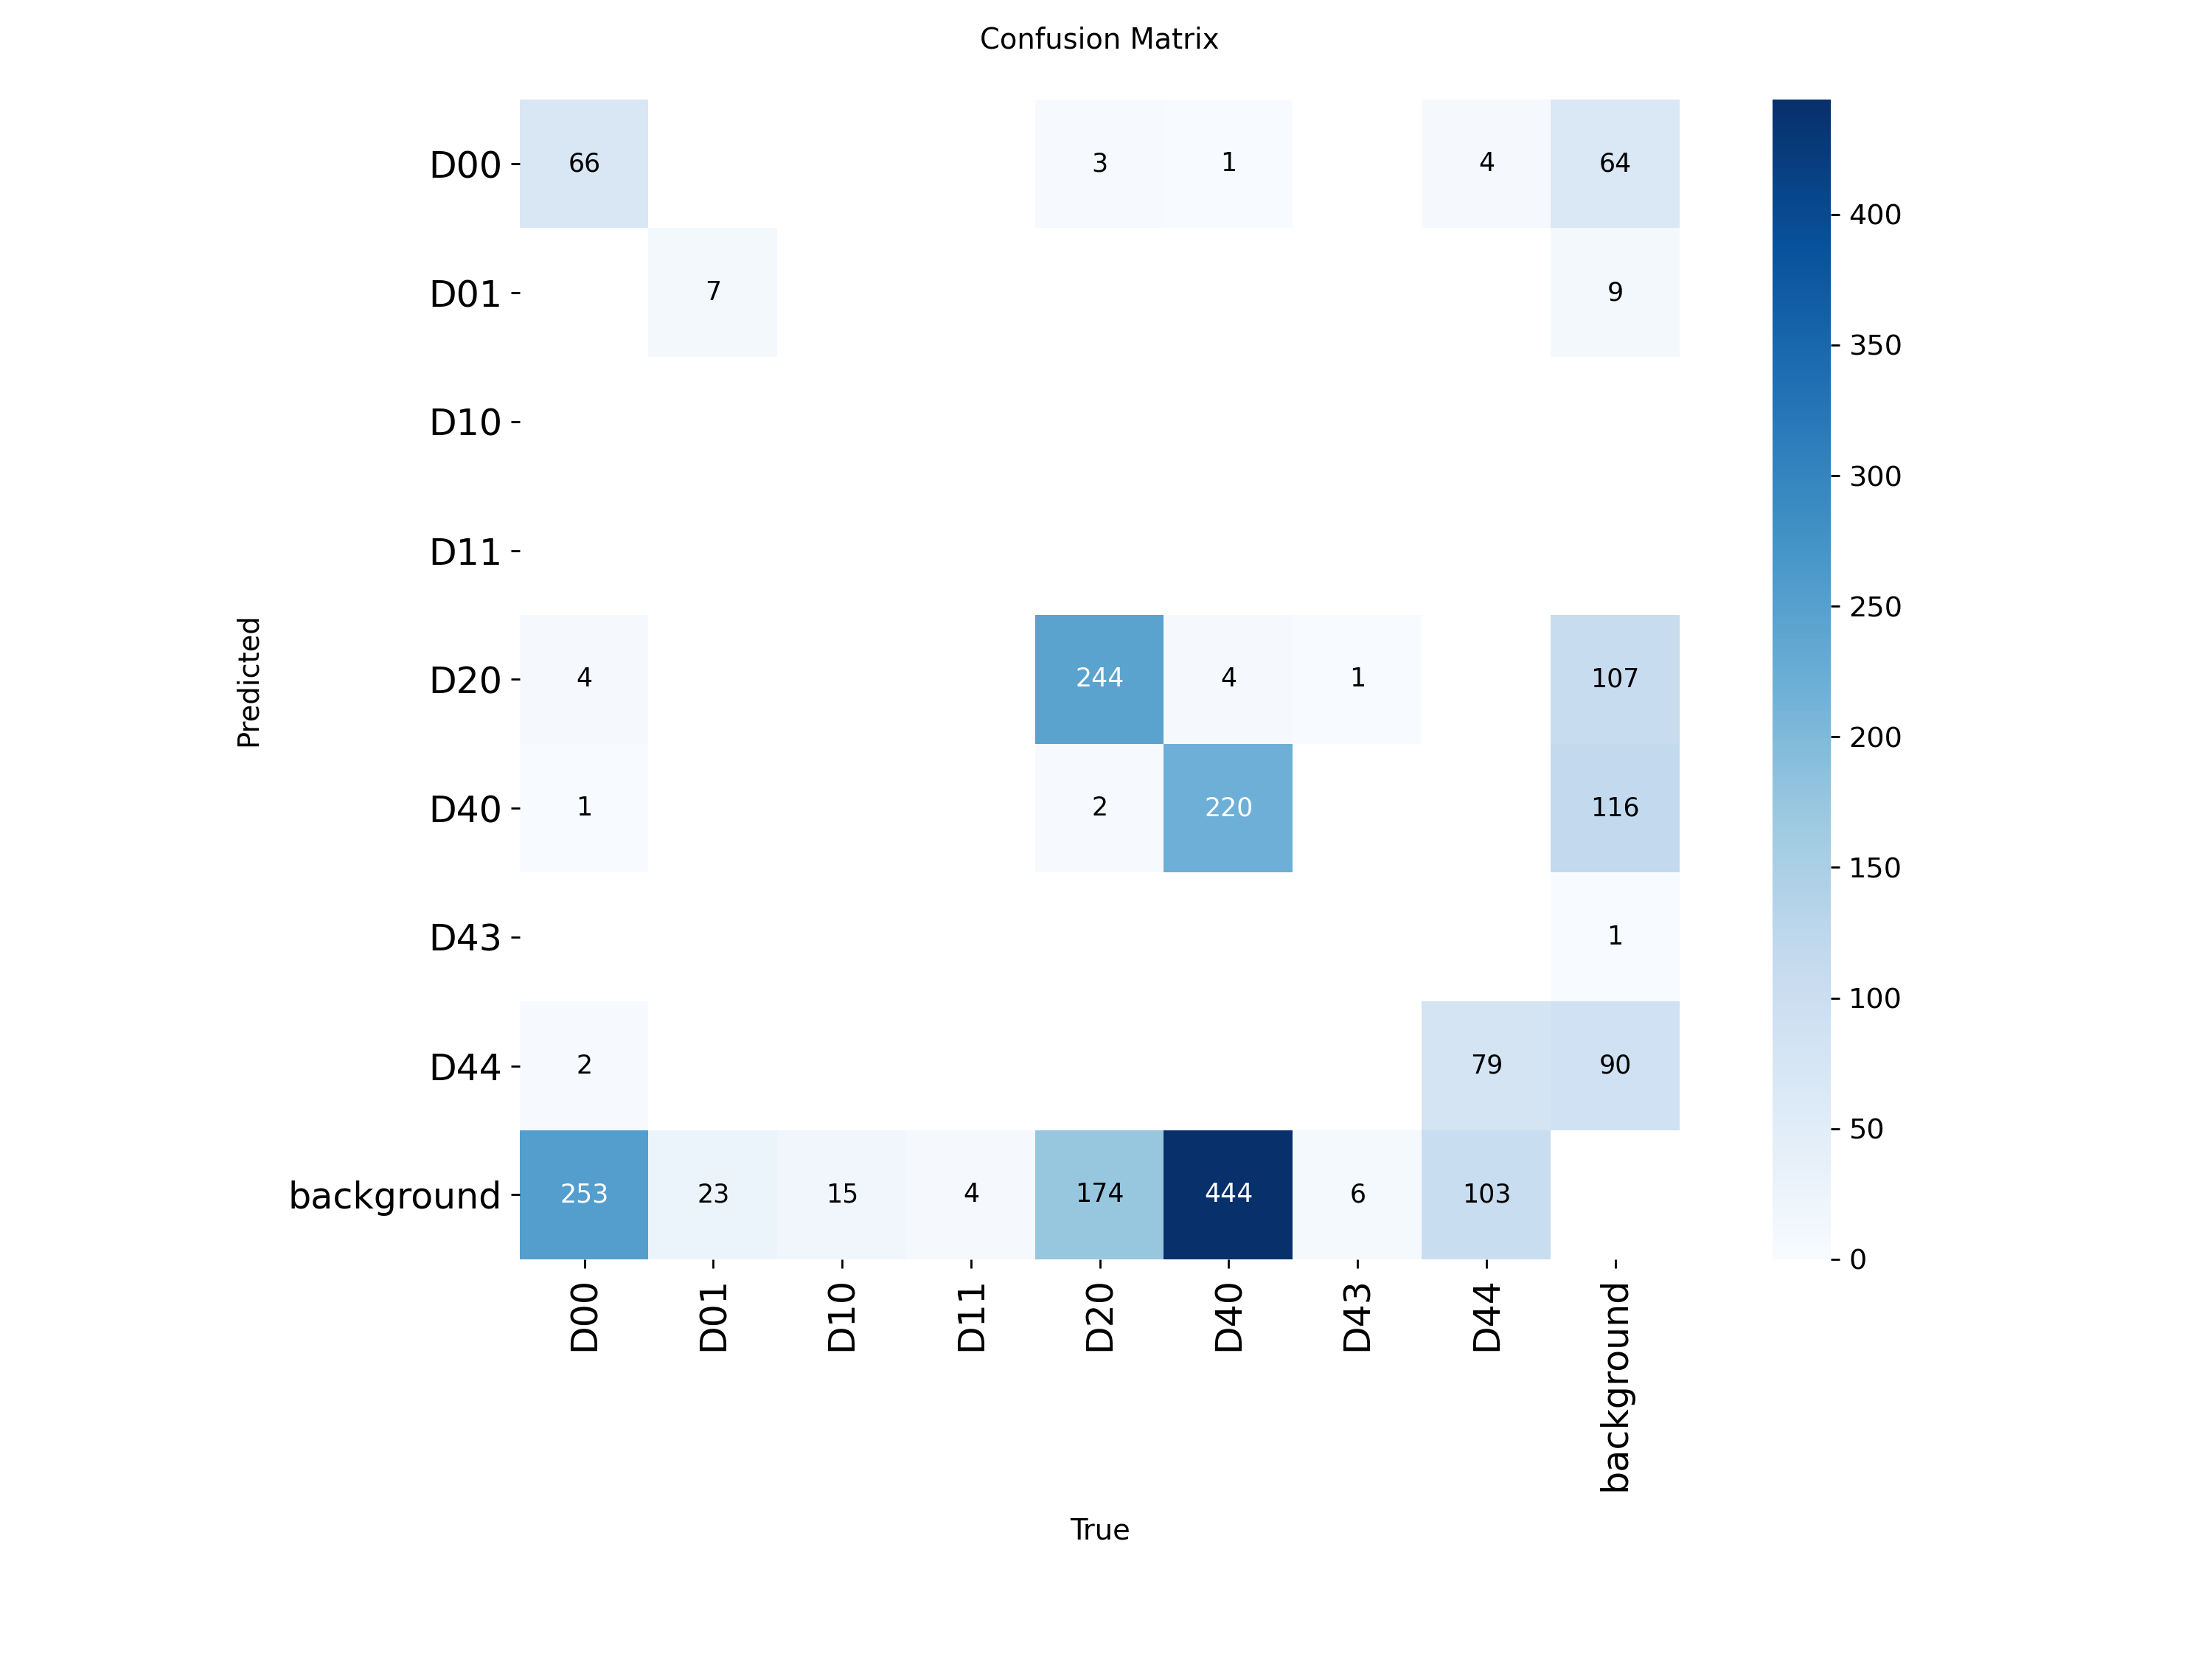

In [22]:
Image("/content/runs/detect/train-2/confusion_matrix.png")